# Lab 2: Classification Using KNN and RNN Algorithms
**Name:** Anushka Nanaware
**Course:** MSCS-634-M50 – Advanced Big Data and Data Mining
**Assignment:** Lab 2 – Classification Using KNN and RNN Algorithms

In [1]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

print("Feature names:", wine.feature_names)
print("Target classes:", wine.target_names)
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['target'].value_counts().sort_index())

df.head()

Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target classes: ['class_0' 'class_1' 'class_2']
Dataset shape: (178, 14)

Class distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [2]:
from sklearn.model_selection import train_test_split

X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (142, 13)
Testing set shape: (36, 13)


In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    knn_accuracies.append(acc)
    print(f"k = {k:2d} -> Accuracy: {acc:.4f}")

k =  1 -> Accuracy: 0.7778
k =  5 -> Accuracy: 0.7222
k = 11 -> Accuracy: 0.7500
k = 15 -> Accuracy: 0.7500
k = 21 -> Accuracy: 0.7778


The accuracy for KNN stays between about 72% and 78% for all the k values I tried. The best results came from k = 1 and k = 21 (both 77.8%), and the lowest was k = 5 (72.2%). The accuracy doesn't go steadily up or down as k grows, so no single k stands out clearly. I didn't scale the features, so a feature with large numbers, like proline, probably has more influence on the distance than the smaller ones. That likely holds the accuracy down.

In [4]:
from sklearn.neighbors import RadiusNeighborsClassifier

radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = []

for r in radius_values:
    rnn = RadiusNeighborsClassifier(radius=r, outlier_label='most_frequent')
    rnn.fit(X_train, y_train)
    y_pred = rnn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    rnn_accuracies.append(acc)
    print(f"radius = {r} -> Accuracy: {acc:.4f}")

radius = 350 -> Accuracy: 0.7500
radius = 400 -> Accuracy: 0.7222
radius = 450 -> Accuracy: 0.7222
radius = 500 -> Accuracy: 0.7222
radius = 550 -> Accuracy: 0.7222
radius = 600 -> Accuracy: 0.7222


RNN scored 75.0% at radius 350, then held steady at 72.2% for every radius from 400 to 600. This makes sense, because a bigger radius pulls more training points into each vote, and once the radius is big enough, adding more points stops changing the predictions. The smallest radius did best, which suggests that looking only at the closest points works better here than a wide neighborhood that mixes in different wine classes.

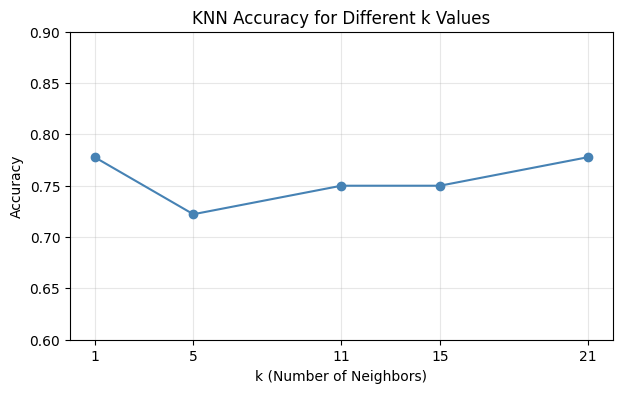

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(k_values, knn_accuracies, marker='o', color='steelblue')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Different k Values')
plt.xticks(k_values)
plt.ylim(0.6, 0.9)
plt.grid(True, alpha=0.3)
plt.show()

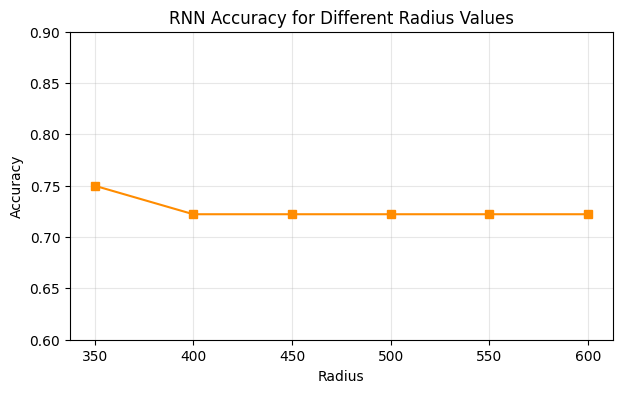

In [6]:
plt.figure(figsize=(7,4))
plt.plot(radius_values, rnn_accuracies, marker='s', color='darkorange')
plt.xlabel('Radius')
plt.ylabel('Accuracy')
plt.title('RNN Accuracy for Different Radius Values')
plt.xticks(radius_values)
plt.ylim(0.6, 0.9)
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
print("Best KNN accuracy:", round(max(knn_accuracies), 4), "at k =", k_values[knn_accuracies.index(max(knn_accuracies))])
print("Best RNN accuracy:", round(max(rnn_accuracies), 4), "at radius =", radius_values[rnn_accuracies.index(max(rnn_accuracies))])
print("Average KNN accuracy:", round(sum(knn_accuracies)/len(knn_accuracies), 4))
print("Average RNN accuracy:", round(sum(rnn_accuracies)/len(rnn_accuracies), 4))

Best KNN accuracy: 0.7778 at k = 1
Best RNN accuracy: 0.75 at radius = 350
Average KNN accuracy: 0.7556
Average RNN accuracy: 0.7269


Comparison: KNN did slightly better than RNN overall. Its best accuracy was 77.8% (k = 1 and k = 21), while RNN's best was 75.0% (radius 350). On average, KNN scored about 75.6% and RNN about 72.7%. KNN's accuracy moved up and down as k changed, while RNN's accuracy went flat once the radius reached 400. That means making the radius bigger did not help. The small gap between the two models is only one or two test samples, since each sample is worth about 2.8% of accuracy with a test set of 36. So I would not say one model is clearly better.

When KNN might be better: KNN is a good choice when the data has a similar density everywhere, or when you want a simple setting to tune (just k). It always finds neighbors, so it never gets stuck with an empty neighborhood.

When RNN might be better: RNN works well when points are packed differently in different areas. In a crowded area it uses many neighbors, and in a sparse area it uses fewer. It's also useful when "close enough" has a real meaning, so that far-away points should never get a vote. The downside is that the radius has to match the scale of the data. In this lab, the radius values only made sense because the features were not scaled, and a poor radius could leave a point with no neighbors.